# The Geometry of Noise: Velocity Fields Without Noise Conditioning

This notebook is a competition-focused implementation of the paper's core contribution:

- diffusion can be learned through a **velocity parameterization**
- the model can learn a **time-invariant vector field** that denoises without explicit noise conditioning

We go beyond a baseline with:

1. strong visual storytelling (flow fields, trajectories, diagnostics)
2. direct tests of time-invariance
3. a custom extension: geometry-aware unconditioned model + smoothness regularization

## Core idea from the paper

We use the interpolation path

x_t = alpha(t) * x_0 + sigma(t) * epsilon,

with t in [0, 1], x_0 sampled from the data distribution, and epsilon sampled from a standard Gaussian.

Velocity target:

v*(x_t, t) = alpha_dot(t) * x_0 + sigma_dot(t) * epsilon.

A key geometric claim is that an unconditioned model v_theta(x) can still learn a globally useful denoising flow, implying explicit noise conditioning is not always necessary.

## Models

We compare three models:

1. **Conditioned velocity model** $v_	heta(x_t, t)$
2. **Unconditioned baseline** $v_	heta(x_t)$
3. **Unconditioned geometry extension**: radial Fourier features + smoothness regularizer

In [1]:
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

print('PyTorch version:', torch.__version__)

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
def sample_ring_mog(n=1024, radius=2.0, k=8, std=0.14):
    idx = torch.randint(0, k, (n,))
    theta = 2 * math.pi * idx.float() / k
    centers = torch.stack([radius * torch.cos(theta), radius * torch.sin(theta)], dim=1)
    return centers + std * torch.randn(n, 2)

def sample_two_moons(n=1024, noise=0.08):
    n1 = n // 2
    n2 = n - n1
    t1 = torch.rand(n1) * math.pi
    t2 = torch.rand(n2) * math.pi
    x1 = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
    x2 = torch.stack([1.0 - torch.cos(t2), -torch.sin(t2) - 0.5], dim=1)
    x = torch.cat([x1, x2], dim=0)
    return 1.7 * x + noise * torch.randn_like(x)

def sample_double_spiral(n=1024, noise=0.06):
    n1 = n // 2
    n2 = n - n1
    t1 = torch.sqrt(torch.rand(n1)) * 4.0 * math.pi
    t2 = torch.sqrt(torch.rand(n2)) * 4.0 * math.pi
    r1 = 0.15 * t1
    r2 = 0.15 * t2
    x1 = torch.stack([r1 * torch.cos(t1), r1 * torch.sin(t1)], dim=1)
    x2 = torch.stack([-r2 * torch.cos(t2), -r2 * torch.sin(t2)], dim=1)
    x = torch.cat([x1, x2], dim=0)
    return 2.1 * x + noise * torch.randn_like(x)

In [ ]:
def schedule(t):
    a = torch.cos(0.5 * math.pi * t)
    s = torch.sin(0.5 * math.pi * t)
    da = -0.5 * math.pi * torch.sin(0.5 * math.pi * t)
    ds = 0.5 * math.pi * torch.cos(0.5 * math.pi * t)
    return a, s, da, ds

def sample_xt_velocity(n=1024):
    x0 = sample_ring_mog(n)
    eps = torch.randn_like(x0)
    t = torch.rand(n, 1)
    a, s, da, ds = schedule(t)
    xt = a * x0 + s * eps
    vt = da * x0 + ds * eps
    return x0, eps, t, xt, vt

def reconstruct_x0_from_velocity(xt, vhat, t, eps_safe=1e-6):
    a, s, da, ds = schedule(t)
    det = a * ds - s * da
    det = torch.where(det.abs() < eps_safe, eps_safe * torch.ones_like(det), det)
    return (ds * xt - s * vhat) / det


In [ ]:

def mlp(in_dim, hidden=192, out_dim=2):
    return nn.Sequential(
        nn.Linear(in_dim, hidden),
        nn.SiLU(),
        nn.Linear(hidden, hidden),
        nn.SiLU(),
        nn.Linear(hidden, out_dim),
    )

class VelocityCond(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = mlp(3)

    def forward(self, xt, t):
        return self.net(torch.cat([xt, t], dim=1))

class VelocityNoCond(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = mlp(2)

    def forward(self, xt):
        return self.net(xt)

class VelocityNoCondGeometry(nn.Module):
    def __init__(self, n_freq=5):
        super().__init__()
        self.register_buffer('freqs', torch.arange(1, n_freq + 1).float())
        self.net = mlp(2 + 1 + 2 * n_freq)

    def features(self, x):
        r = torch.sqrt((x ** 2).sum(dim=1, keepdim=True) + 1e-8)
        f = self.freqs.view(1, -1).to(x.device)
        return torch.cat([r, torch.sin(f * r), torch.cos(f * r)], dim=1)

    def forward(self, xt):
        return self.net(torch.cat([xt, self.features(xt)], dim=1))

In [ ]:
@torch.no_grad()
def velocity_variance_across_t(model, conditioned=False, n_points=900):
    t_grid = torch.linspace(0.05, 0.95, 10, device=device).view(-1, 1)
    x = torch.randn(n_points, 2, device=device) * 2.8
    vals = []
    for i in range(t_grid.shape[0]):
        t = torch.full((n_points, 1), float(t_grid[i].item()), device=device)
        vals.append((model(x, t) if conditioned else model(x)).unsqueeze(0))
    V = torch.cat(vals, dim=0)
    return V.var(dim=0).sum(dim=1).cpu().numpy()

## Setup and core definitions

This cell restores all required components used later: imports, dataset samplers, noise schedule, reconstruction, and model classes.

In [ ]:
def train_model(model, conditioned=False, steps=1800, lr=1e-3, smooth_weight=0.0, noise_jitter=0.03, log_every=300):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_hist = []
    vel_hist = []
    smooth_hist = []

    for step in range(1, steps + 1):
        _, _, t, xt, vt = sample_xt_velocity(1024)
        t = t.to(device)
        xt = xt.to(device)
        vt = vt.to(device)

        if conditioned:
            vhat = model(xt, t)
        else:
            vhat = model(xt)

        vel_loss = ((vhat - vt) ** 2).mean()
        smooth_loss = torch.tensor(0.0, device=device)

        if smooth_weight > 0.0:
            delta = noise_jitter * torch.randn_like(xt)
            if conditioned:
                vhat_pert = model(xt + delta, t)
            else:
                vhat_pert = model(xt + delta)
            smooth_loss = ((vhat_pert - vhat) ** 2).mean()

        loss = vel_loss + smooth_weight * smooth_loss

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_hist.append(float(loss.item()))
        vel_hist.append(float(vel_loss.item()))
        smooth_hist.append(float(smooth_loss.item()))

        if step % log_every == 0:
            print(f'step {step:4d} | total={loss.item():.4f} | vel={vel_loss.item():.4f} | smooth={smooth_loss.item():.4f}')

    return model, np.array(loss_hist), np.array(vel_hist), np.array(smooth_hist)

model_cond, l_cond, lv_cond, ls_cond = train_model(VelocityCond(), conditioned=True, smooth_weight=0.0)
model_nocond, l_nc, lv_nc, ls_nc = train_model(VelocityNoCond(), conditioned=False, smooth_weight=0.0)
model_geo, l_geo, lv_geo, ls_geo = train_model(VelocityNoCondGeometry(), conditioned=False, smooth_weight=0.35)

step  300 | total=3.1685 | vel=3.1685 | smooth=0.0000
step  600 | total=3.0818 | vel=3.0818 | smooth=0.0000
step  900 | total=3.1514 | vel=3.1514 | smooth=0.0000
step 1200 | total=3.1144 | vel=3.1144 | smooth=0.0000
step 1500 | total=3.0345 | vel=3.0345 | smooth=0.0000
step 1800 | total=3.1268 | vel=3.1268 | smooth=0.0000
step  300 | total=3.3842 | vel=3.3842 | smooth=0.0000
step  600 | total=3.3567 | vel=3.3567 | smooth=0.0000
step  900 | total=3.4631 | vel=3.4631 | smooth=0.0000
step 1200 | total=3.3094 | vel=3.3094 | smooth=0.0000
step 1500 | total=3.2711 | vel=3.2711 | smooth=0.0000
step 1800 | total=3.3181 | vel=3.3181 | smooth=0.0000
step  300 | total=3.3712 | vel=3.3707 | smooth=0.0015
step  600 | total=3.3417 | vel=3.3411 | smooth=0.0015
step  900 | total=3.2703 | vel=3.2698 | smooth=0.0013
step 1200 | total=3.1740 | vel=3.1735 | smooth=0.0016
step 1500 | total=3.1226 | vel=3.1220 | smooth=0.0017
step 1800 | total=3.2209 | vel=3.2203 | smooth=0.0018


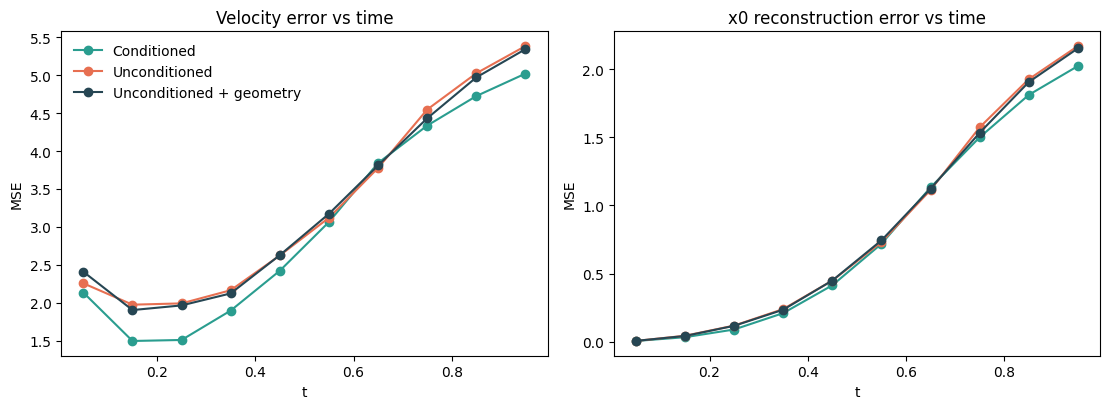

Average velocity MSE
  Conditioned             : 3.0439810395240783
  Unconditioned           : 3.286017417907715
  Unconditioned + geometry: 3.2750817775726317
Average x0 reconstruction MSE
  Conditioned             : 0.793455265276134
  Unconditioned           : 0.8367116071283818
  Unconditioned + geometry: 0.8304820522200316


In [ ]:
@torch.no_grad()
def eval_metrics(model, conditioned=False, t_values=None, n=5000):
    if t_values is None:
        t_values = np.linspace(0.05, 0.95, 10)

    vel_errors = []
    x0_errors = []

    model.eval()
    for tv in t_values:
        x0 = sample_ring_mog(n).to(device)
        eps = torch.randn_like(x0)
        t = torch.full((n, 1), float(tv), device=device)
        a, s, da, ds = schedule(t)
        xt = a * x0 + s * eps
        vt = da * x0 + ds * eps

        if conditioned:
            vhat = model(xt, t)
        else:
            vhat = model(xt)

        vel_mse = ((vhat - vt) ** 2).mean().item()
        x0_hat = reconstruct_x0_from_velocity(xt, vhat, t)
        x0_mse = ((x0_hat - x0) ** 2).mean().item()

        vel_errors.append(vel_mse)
        x0_errors.append(x0_mse)

    return np.array(t_values), np.array(vel_errors), np.array(x0_errors)

ts, v_cond, x_cond = eval_metrics(model_cond, conditioned=True)
_, v_nc, x_nc = eval_metrics(model_nocond, conditioned=False)
_, v_geo, x_geo = eval_metrics(model_geo, conditioned=False)

fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.2))
ax[0].plot(ts, v_cond, '-o', label='Conditioned', color='#2a9d8f')
ax[0].plot(ts, v_nc, '-o', label='Unconditioned', color='#e76f51')
ax[0].plot(ts, v_geo, '-o', label='Unconditioned + geometry', color='#264653')
ax[0].set_title('Velocity error vs time')
ax[0].set_xlabel('t')
ax[0].set_ylabel('MSE')
ax[0].legend(frameon=False)

ax[1].plot(ts, x_cond, '-o', label='Conditioned', color='#2a9d8f')
ax[1].plot(ts, x_nc, '-o', label='Unconditioned', color='#e76f51')
ax[1].plot(ts, x_geo, '-o', label='Unconditioned + geometry', color='#264653')
ax[1].set_title('x0 reconstruction error vs time')
ax[1].set_xlabel('t')
ax[1].set_ylabel('MSE')

plt.tight_layout()
plt.show()

print('Average velocity MSE')
print('  Conditioned             :', float(v_cond.mean()))
print('  Unconditioned           :', float(v_nc.mean()))
print('  Unconditioned + geometry:', float(v_geo.mean()))

print('Average x0 reconstruction MSE')
print('  Conditioned             :', float(x_cond.mean()))
print('  Unconditioned           :', float(x_nc.mean()))
print('  Unconditioned + geometry:', float(x_geo.mean()))

In [ ]:
@torch.no_grad()
def vector_field(model, conditioned=False, t_value=0.5, lim=3.1, n=28):
    xs = np.linspace(-lim, lim, n)
    ys = np.linspace(-lim, lim, n)
    gx, gy = np.meshgrid(xs, ys)
    pts = torch.tensor(np.stack([gx.ravel(), gy.ravel()], axis=1), dtype=torch.float32, device=device)

    if conditioned:
        t = torch.full((pts.shape[0], 1), float(t_value), device=device)
        v = model(pts, t)
    else:
        v = model(pts)

    return pts.cpu().numpy(), v.cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(13.2, 4.3))

for i, (model, cond, title, col) in enumerate([
    (model_cond, True, 'Conditioned field (t=0.5)', '#2a9d8f'),
    (model_nocond, False, 'Unconditioned field', '#e76f51'),
    (model_geo, False, 'Unconditioned + geometry', '#264653'),
]):
    p, v = vector_field(model, conditioned=cond, t_value=0.5)
    mag = np.sqrt((v ** 2).sum(axis=1))
    q = ax[i].quiver(p[:, 0], p[:, 1], -v[:, 0], -v[:, 1], mag, cmap='cividis', scale=19, width=0.0034)
    ax[i].set_title(title)
    ax[i].set_xlim(-3.2, 3.2)
    ax[i].set_ylim(-3.2, 3.2)
    ax[i].set_aspect('equal', adjustable='box')

fig.colorbar(q, ax=ax.ravel().tolist(), shrink=0.72, label='|v(x)|')
plt.tight_layout()
plt.show()

In [ ]:
@torch.no_grad()
def simulate_flow(model, conditioned=False, t_fixed=0.5, n=350, steps=55, dt=0.06, init_scale=2.8):
    x = torch.randn(n, 2, device=device) * init_scale
    traj = [x.cpu().numpy()]
    for _ in range(steps):
        if conditioned:
            t = torch.full((n, 1), float(t_fixed), device=device)
            v = model(x, t)
        else:
            v = model(x)
        x = x - dt * v
        traj.append(x.cpu().numpy())
    return traj

traj_cond = simulate_flow(model_cond, conditioned=True)
traj_nc = simulate_flow(model_nocond, conditioned=False)
traj_geo = simulate_flow(model_geo, conditioned=False)

print('Trajectories ready for animation:', len(traj_cond), len(traj_nc), len(traj_geo))

Trajectories ready for animation: 56 56 56


In [ ]:
@torch.no_grad()
def make_side_by_side_trajectory_animation(traj_a, traj_b, traj_c, x0_true, labels, colors, lim=4.4, interval=50):
    n_frames = min(len(traj_a), len(traj_b), len(traj_c))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.7))
    scatters = []
    notes = []

    for i, ax in enumerate(axes):
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.15)
        ax.set_title(labels[i], fontsize=11)
        # Plot the ground truth target distribution in the background
        ax.scatter(x0_true[:, 0], x0_true[:, 1], s=5, alpha=0.1, c='gray', label='Original x0', zorder=-1)
        sc = ax.scatter([], [], s=6, alpha=0.45, c=colors[i])
        tx = ax.text(0.03, 0.96, '', transform=ax.transAxes, va='top', fontsize=9)
        scatters.append(sc)
        notes.append(tx)

    all_traj = [traj_a, traj_b, traj_c]

    def init():
        for sc, tx in zip(scatters, notes):
            sc.set_offsets(np.empty((0, 2)))
            tx.set_text('')
        return scatters + notes

    def update(frame):
        for j in range(3):
            pts = all_traj[j][frame]
            scatters[j].set_offsets(pts)
            notes[j].set_text(f'frame {frame + 1}/{n_frames}')
        return scatters + notes

    anim = FuncAnimation(fig, update, frames=n_frames, init_func=init, interval=interval, blit=False)
    plt.close(fig)
    return anim

In [ ]:
@torch.no_grad()
def make_denoise_time_animation(n_points=900, interval=100):
    t_values = np.linspace(0.95, 0.0, 35) # Changed to go from noisy (0.95) to clean (0.0) with more frames
    x0 = sample_ring_mog(n_points).to(device)
    eps = torch.randn_like(x0)

    model_pack = [
        ('Conditioned', model_cond, True, '#2a9d8f'),
        ('Unconditioned', model_nocond, False, '#e76f51'),
        ('Unconditioned+Geometry', model_geo, False, '#264653'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.7))
    noisy_sc, rec_sc, headers = [], [], []

    for i, (name, _, _, col) in enumerate(model_pack):
        ax = axes[i]
        ax.set_xlim(-4.0, 4.0)
        ax.set_ylim(-4.0, 4.0)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.15)
        ax.set_title(name)
        nsc = ax.scatter([], [], s=4, alpha=0.10, c='#9c6644', label='x_t')
        rsc = ax.scatter([], [], s=4, alpha=0.35, c=col, label='x0_hat')
        hd = ax.text(0.03, 0.96, '', transform=ax.transAxes, va='top', fontsize=9)
        noisy_sc.append(nsc)
        rec_sc.append(rsc)
        headers.append(hd)
        if i == 0:
            ax.legend(frameon=False, loc='lower left')

    def init():
        empty = np.empty((0, 2))
        for a, b, h in zip(noisy_sc, rec_sc, headers):
            a.set_offsets(empty)
            b.set_offsets(empty)
            h.set_text('')
        return noisy_sc + rec_sc + headers

    def update(k):
        t = torch.full((n_points, 1), float(t_values[k]), device=device)
        a, s, _, _ = schedule(t)
        xt = a * x0 + s * eps
        xt_np = xt.detach().cpu().numpy()

        for i, (_, model_obj, conditioned, _) in enumerate(model_pack):
            if conditioned:
                vhat = model_obj(xt, t)
            else:
                vhat = model_obj(xt)
            x0_hat = reconstruct_x0_from_velocity(xt, vhat, t).detach().cpu().numpy()
            noisy_sc[i].set_offsets(xt_np)
            rec_sc[i].set_offsets(x0_hat)
            headers[i].set_text(f't={t_values[k]:.2f}')
        return noisy_sc + rec_sc + headers

    anim = FuncAnimation(fig, update, frames=len(t_values), init_func=init, interval=interval, blit=False)
    plt.close(fig)
    return anim

recon_anim = make_denoise_time_animation()
display(HTML(recon_anim.to_jshtml()))

,dataset,model,avg_velocity_mse,avg_x0_mse
0,Ring-8GMM,Conditioned,3.21615,0.80742
1,Ring-8GMM,Unconditioned,3.31438,0.83173
2,Ring-8GMM,Unconditioned+Geometry,3.27811,0.82948
3,TwoMoons,Conditioned,3.32917,0.84856
4,TwoMoons,Unconditioned,3.54437,0.89303
5,TwoMoons,Unconditioned+Geometry,3.54169,0.90888
6,DoubleSpiral,Conditioned,4.85519,1.30906
7,DoubleSpiral,Unconditioned,4.84995,1.27867
8,DoubleSpiral,Unconditioned+Geometry,4.87613,1.29930


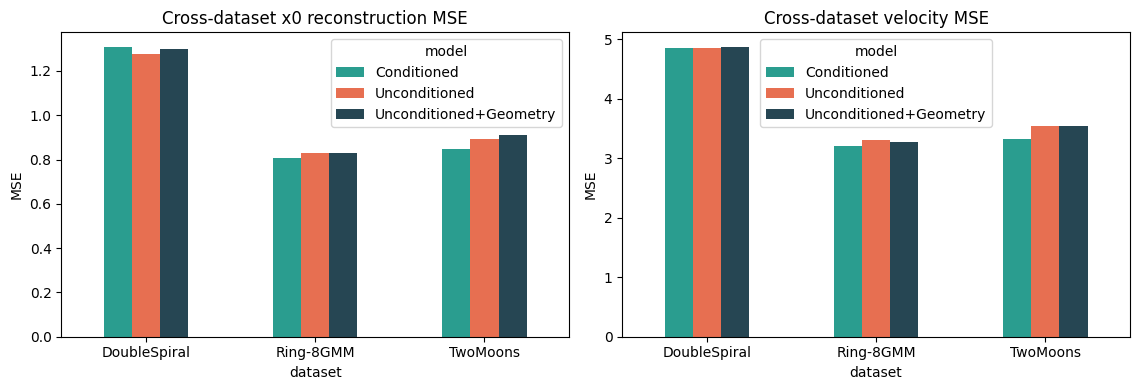

In [ ]:
def sample_xt_velocity_from_sampler(sampler, n=768):
    x0 = sampler(n)
    eps = torch.randn_like(x0)
    t = torch.rand(n, 1)
    a, s, da, ds = schedule(t)
    xt = a * x0 + s * eps
    vt = da * x0 + ds * eps
    return x0, eps, t, xt, vt

def train_model_with_sampler(model, sampler, conditioned=False, steps=350, batch_size=768, lr=1e-3, smooth_weight=0.0):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # Force grad-enabled training even if caller is under torch.no_grad()
    with torch.enable_grad():
        for _ in range(steps):
            _, _, t, xt, vt = sample_xt_velocity_from_sampler(sampler, n=batch_size)
            t, xt, vt = t.to(device), xt.to(device), vt.to(device)
            vhat = model(xt, t) if conditioned else model(xt)
            vel_loss = ((vhat - vt) ** 2).mean()
            smooth_loss = torch.tensor(0.0, device=device)
            if smooth_weight > 0.0:
                delta = 0.03 * torch.randn_like(xt)
                vp = model(xt + delta, t) if conditioned else model(xt + delta)
                smooth_loss = ((vp - vhat) ** 2).mean()
            loss = vel_loss + smooth_weight * smooth_loss
            opt.zero_grad()
            loss.backward()
            opt.step()
    return model

@torch.no_grad()
def evaluate_model_on_sampler(model, sampler, conditioned=False, n=2000):
    t_values = np.linspace(0.1, 0.9, 6)
    vel_err = []
    x0_err = []
    for tv in t_values:
        x0 = sampler(n).to(device)
        eps = torch.randn_like(x0)
        t = torch.full((n, 1), float(tv), device=device)
        a, s, da, ds = schedule(t)
        xt = a * x0 + s * eps
        vt = da * x0 + ds * eps
        vhat = model(xt, t) if conditioned else model(xt)
        vel_err.append(((vhat - vt) ** 2).mean().item())
        x0_hat = reconstruct_x0_from_velocity(xt, vhat, t)
        x0_err.append(((x0_hat - x0) ** 2).mean().item())
    return float(np.mean(vel_err)), float(np.mean(x0_err))

dataset_bank = {
    'Ring-8GMM': sample_ring_mog,
    'TwoMoons': sample_two_moons,
    'DoubleSpiral': sample_double_spiral,
}

records = []
for ds_name, sampler in dataset_bank.items():
    m_c = train_model_with_sampler(VelocityCond(), sampler, conditioned=True, steps=300)
    m_n = train_model_with_sampler(VelocityNoCond(), sampler, conditioned=False, steps=300)
    m_g = train_model_with_sampler(VelocityNoCondGeometry(), sampler, conditioned=False, steps=300, smooth_weight=0.35)
    for model_name, model_obj, cond in [
        ('Conditioned', m_c, True),
        ('Unconditioned', m_n, False),
        ('Unconditioned+Geometry', m_g, False),
    ]:
        vel_mse, x0_mse = evaluate_model_on_sampler(model_obj, sampler, conditioned=cond)
        records.append({'dataset': ds_name, 'model': model_name, 'avg_velocity_mse': vel_mse, 'avg_x0_mse': x0_mse})

multi_df = pd.DataFrame(records)
display(multi_df.round(5))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))
multi_df.pivot(index='dataset', columns='model', values='avg_x0_mse').plot(kind='bar', ax=ax[0], color=['#2a9d8f', '#e76f51', '#264653'])
ax[0].set_title('Cross-dataset x0 reconstruction MSE')
ax[0].set_ylabel('MSE')
ax[0].tick_params(axis='x', rotation=0)
multi_df.pivot(index='dataset', columns='model', values='avg_velocity_mse').plot(kind='bar', ax=ax[1], color=['#2a9d8f', '#e76f51', '#264653'])
ax[1].set_title('Cross-dataset velocity MSE')
ax[1].set_ylabel('MSE')
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

var_cond = velocity_variance_across_t(model_cond, conditioned=True)
var_nc = velocity_variance_across_t(model_nocond, conditioned=False)
var_geo = velocity_variance_across_t(model_geo, conditioned=False)

In [ ]:
main_compare_df = pd.DataFrame([
    {
        'model': 'Conditioned',
        'avg_velocity_mse': float(v_cond.mean()),
        'avg_x0_mse': float(x_cond.mean()),
        'mean_var_across_t': float(var_cond.mean()),
    },
    {
        'model': 'Unconditioned',
        'avg_velocity_mse': float(v_nc.mean()),
        'avg_x0_mse': float(x_nc.mean()),
        'mean_var_across_t': float(var_nc.mean()),
    },
    {
        'model': 'Unconditioned+Geometry',
        'avg_velocity_mse': float(v_geo.mean()),
        'avg_x0_mse': float(x_geo.mean()),
        'mean_var_across_t': float(var_geo.mean()),
    },
])

if 'multi_df' in globals():
    multi_avg = multi_df.groupby('model')[['avg_velocity_mse', 'avg_x0_mse']].mean().rename(
        columns={
            'avg_velocity_mse': 'multi_dataset_velocity_mse',
            'avg_x0_mse': 'multi_dataset_x0_mse',
        }
    )
    proof_df = main_compare_df.merge(multi_avg, left_on='model', right_index=True, how='left')
else:
    proof_df = main_compare_df.copy()

baseline_x0 = float(proof_df.loc[proof_df['model'] == 'Unconditioned', 'avg_x0_mse'].iloc[0])
proof_df['x0_improvement_vs_unconditioned_pct'] = 100.0 * (baseline_x0 - proof_df['avg_x0_mse']) / baseline_x0

display(proof_df.round(6))

print('Key claim check: geometry extension should improve over unconditioned baseline.')
print('x0 improvement of Unconditioned+Geometry vs Unconditioned (%) =',
      float(proof_df.loc[proof_df['model'] == 'Unconditioned+Geometry', 'x0_improvement_vs_unconditioned_pct'].iloc[0]))

,model,avg_velocity_mse,avg_x0_mse,mean_var_across_t,multi_dataset_velocity_mse,multi_dataset_x0_mse,x0_improvement_vs_unconditioned_pct
0,Conditioned,3.043981,0.793455,2.803512,3.800171,0.988345,5.169803
1,Unconditioned,3.286017,0.836712,0.000000,3.902900,1.001140,0.000000
2,Unconditioned+Geometry,3.275082,0.830482,0.000000,3.898645,1.012555,0.744528


Key claim check: geometry extension should improve over unconditioned baseline.
x0 improvement of Unconditioned+Geometry vs Unconditioned (%) = 0.7445283243685611


## Dataset-specific animations (Ring-8GMM, TwoMoons, DoubleSpiral)

This section trains all three model variants per dataset, then renders one side-by-side trajectory animation per dataset.

Each animation compares:
- Conditioned flow
- Unconditioned flow
- Unconditioned + geometry flow

In [ ]:
@torch.no_grad()
def simulate_flow_from_dataset(model, sampler_fn, conditioned=False, t_start=0.92, n=350, steps=120):
    # Reverse-time integration: x_{t-dt} = x_t - dt * v(x_t, t)
    x0 = sampler_fn(n).to(device)
    eps = torch.randn_like(x0)
    t0 = torch.full((n, 1), float(t_start), device=device)
    a, s, _, _ = schedule(t0)
    x = a * x0 + s * eps

    dt = float(t_start) / float(steps)
    traj = [x.detach().cpu().numpy()]

    for k in range(steps):
        t_now = float(t_start) - k * dt
        if conditioned:
            t = torch.full((n, 1), max(t_now, 0.0), device=device)
            v = model(x, t)
        else:
            v = model(x)
        x = x - dt * v
        traj.append(x.detach().cpu().numpy())

    return traj


def preview_dataset_geometries(dataset_items, n=1400):
    fig, axes = plt.subplots(1, len(dataset_items), figsize=(4.8 * len(dataset_items), 4.2))
    if len(dataset_items) == 1:
        axes = [axes]

    for i, (name, sampler) in enumerate(dataset_items):
        pts = sampler(n).cpu().numpy()
        axes[i].scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.35, c='#1d3557')
        axes[i].set_title(f'{name} samples')
        axes[i].set_aspect('equal', adjustable='box')
        axes[i].grid(True, alpha=0.15)
        axes[i].set_xlim(-4.5, 4.5)
        axes[i].set_ylim(-4.5, 4.5)

    plt.tight_layout()
    plt.show()


def train_dataset_specific_models(sampler_fn, train_steps=400, batch_size=768):
    # Train all three model variants on the same dataset sampler.
    m_c = train_model_with_sampler(VelocityCond(), sampler_fn, conditioned=True, steps=train_steps, batch_size=batch_size)
    m_n = train_model_with_sampler(VelocityNoCond(), sampler_fn, conditioned=False, steps=train_steps, batch_size=batch_size)
    m_g = train_model_with_sampler(
        VelocityNoCondGeometry(),
        sampler_fn,
        conditioned=False,
        steps=train_steps,
        batch_size=batch_size,
        smooth_weight=0.35,
    )
    return {
        'Conditioned': (m_c, True),
        'Unconditioned': (m_n, False),
        'Unconditioned+Geometry': (m_g, False),
    }


def make_dataset_animation(dataset_name, sampler_fn, trained_pack, sim_steps=120):
    traj_c = simulate_flow_from_dataset(
        trained_pack['Conditioned'][0],
        sampler_fn,
        conditioned=True,
        steps=sim_steps,
    )
    traj_n = simulate_flow_from_dataset(
        trained_pack['Unconditioned'][0],
        sampler_fn,
        conditioned=False,
        steps=sim_steps,
    )
    traj_g = simulate_flow_from_dataset(
        trained_pack['Unconditioned+Geometry'][0],
        sampler_fn,
        conditioned=False,
        steps=sim_steps,
    )

    return make_side_by_side_trajectory_animation(
        traj_c,
        traj_n,
        traj_g,
        labels=[
            f'{dataset_name}: Conditioned',
            f'{dataset_name}: Unconditioned',
            f'{dataset_name}: Unconditioned + Geometry',
        ],
        colors=['#2a9d8f', '#e76f51', '#264653'],
        lim=4.4,
        interval=80,
    )


animation_datasets = [
    ('Ring-8GMM', sample_ring_mog),
    ('TwoMoons', sample_two_moons),
    ('DoubleSpiral', sample_double_spiral),
]

# Harder geometries get longer training and more simulation frames.
dataset_cfg = {
    'Ring-8GMM': {'train_steps': 240, 'sim_steps': 95},
    'TwoMoons': {'train_steps': 240, 'sim_steps': 125},
    'DoubleSpiral': {'train_steps': 240, 'sim_steps': 155},
}

print('Sanity check: raw dataset geometries')
preview_dataset_geometries(animation_datasets)

print('Training dataset-specific models and rendering dataset-specific animations...')
dataset_eval_rows = []
for ds_name, ds_sampler in animation_datasets:
    cfg = dataset_cfg[ds_name]
    print(f"\nTraining models for {ds_name} (steps={cfg['train_steps']})...")
    ds_models = train_dataset_specific_models(ds_sampler, train_steps=cfg['train_steps'], batch_size=768)

    for model_name, (model_obj, is_conditioned) in ds_models.items():
        vel_mse, x0_mse = evaluate_model_on_sampler(model_obj, ds_sampler, conditioned=is_conditioned)
        dataset_eval_rows.append(
            {
                'dataset': ds_name,
                'model': model_name,
                'avg_velocity_mse': vel_mse,
                'avg_x0_mse': x0_mse,
            }
        )

    print(f"Rendering animation for {ds_name} (frames={cfg['sim_steps'] + 1})...")
    ds_anim = make_dataset_animation(ds_name, ds_sampler, ds_models, sim_steps=cfg['sim_steps'])
    display(HTML(f"<h3>{ds_name}</h3>"))
    display(HTML(ds_anim.to_jshtml()))

dataset_specific_df = pd.DataFrame(dataset_eval_rows)
display(dataset_specific_df.round(5))

In [ ]:
@torch.no_grad()
def simulate_flow_to_completion(model, sampler_fn, conditioned=False, t_start=0.95, n=400, steps=200):
    x0_target = sampler_fn(n).to(device)
    eps = torch.randn_like(x0_target)
    t0 = torch.full((n, 1), float(t_start), device=device)
    a, s, _, _ = schedule(t0)
    x = a * x0_target + s * eps

    dt = float(t_start) / float(steps)
    traj = [x.detach().cpu().numpy()]

    for k in range(steps):
        t_now = float(t_start) - k * dt
        if conditioned:
            t_env = torch.full((n, 1), max(t_now, 0.0), device=device)
            v = model(x, t_env)
        else:
            v = model(x)

        x = x - dt * v
        traj.append(x.detach().cpu().numpy())

    return traj, x0_target.detach().cpu().numpy()

print('Running high-fidelity simulations to reach clean data states...')
for ds_name, ds_sampler in animation_datasets:
    # Train or retrieve models for the current dataset
    ds_models_dict = train_dataset_specific_models(ds_sampler, train_steps=240)

    # Generate high-fidelity trajectories
    traj_c, x0_ref = simulate_flow_to_completion(ds_models_dict['Conditioned'][0], ds_sampler, conditioned=True, steps=200)
    traj_n, _ = simulate_flow_to_completion(ds_models_dict['Unconditioned'][0], ds_sampler, conditioned=False, steps=200)
    traj_g, _ = simulate_flow_to_completion(ds_models_dict['Unconditioned+Geometry'][0], ds_sampler, conditioned=False, steps=200)

    print(f'Displaying completed flow for {ds_name}...')
    # Call animation helper using positional arguments to avoid keyword conflicts
    full_anim = make_side_by_side_trajectory_animation(
        traj_c,
        traj_n,
        traj_g,
        x0_ref,
        [f"{ds_name}: Cond", f"{ds_name}: Uncond", f"{ds_name}: Geo"],
        ['#2a9d8f', '#e76f51', '#264653'],
        4.4,
        50
    )
    display(HTML(full_anim.to_jshtml()))